--- Loading Data ---


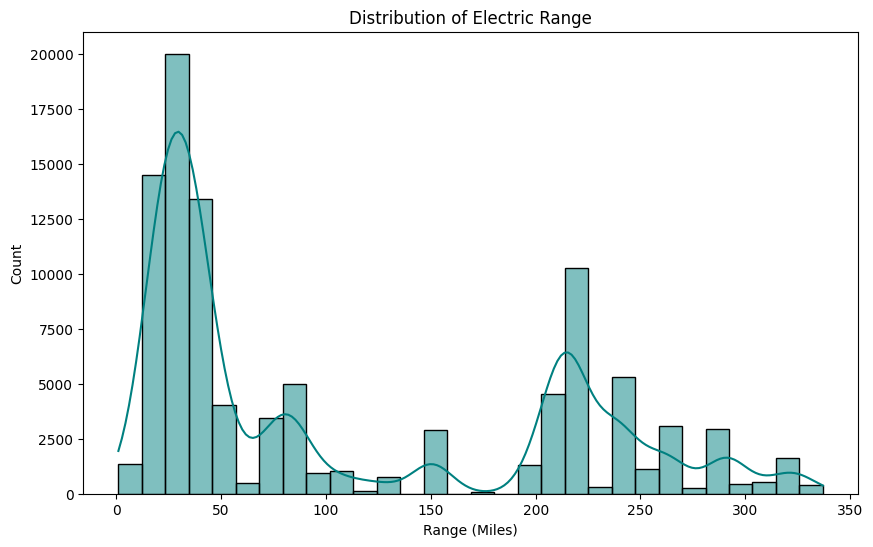

--- Training Model ---
--- Evaluating Model ---
Mean Absolute Error: 3.48 miles
R-squared Score: 0.9918

Predicted Range for a 2022 Tesla BEV: 297.22 miles


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

def run_ev_ml_project(csv_path):
    # 1. Load Dataset
    print("--- Loading Data ---")
    try:
        df = pd.read_csv(csv_path)
    except FileNotFoundError:
        print(f"Error: File not found at {csv_path}. Please download the CSV from Data.gov.")
        return

    # 2. Basic Cleaning
    # The full column name in the Data.gov dataset is 'Clean Alternative Fuel Vehicle (CAFV) Eligibility'
    target = 'Electric Range'
    
    # Filter for rows where Range is > 0 (many 0s represent placeholder data)
    df_clean = df[df[target] > 0].copy()
    
    # Selecting relevant features using the exact column names from the dataset
    features = [
        'Model Year', 
        'Make', 
        'Electric Vehicle Type', 
        'Clean Alternative Fuel Vehicle (CAFV) Eligibility'
    ]
    
    X = df_clean[features]
    y = df_clean[target]

    # 3. Exploratory Data Analysis (EDA) Snippet
    plt.figure(figsize=(10, 6))
    sns.histplot(y, bins=30, kde=True, color='teal')
    plt.title('Distribution of Electric Range')
    plt.xlabel('Range (Miles)')
    plt.show()

    # 4. Preprocessing Pipeline
    numeric_features = ['Model Year']
    categorical_features = [
        'Make', 
        'Electric Vehicle Type', 
        'Clean Alternative Fuel Vehicle (CAFV) Eligibility'
    ]

    # Preprocessor for categorical and numerical data
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), numeric_features),
            ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
        ])

    # 5. Create the Model Pipeline
    model_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
    ])

    # 6. Split and Train
    print("--- Training Model ---")
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    model_pipeline.fit(X_train, y_train)

    # 7. Evaluate
    print("--- Evaluating Model ---")
    y_pred = model_pipeline.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f"Mean Absolute Error: {mae:.2f} miles")
    print(f"R-squared Score: {r2:.4f}")

    # 8. Practical Prediction Test
    test_sample = pd.DataFrame({
        'Model Year': [2022],
        'Make': ['TESLA'],
        'Electric Vehicle Type': ['Battery Electric Vehicle (BEV)'],
        'Clean Alternative Fuel Vehicle (CAFV) Eligibility': ['Clean Alternative Fuel Vehicle Eligible']
    })
    
    predicted_range = model_pipeline.predict(test_sample)
    print(f"\nPredicted Range for a 2022 Tesla BEV: {predicted_range[0]:.2f} miles")

if __name__ == "__main__":
    # Update this path to where your downloaded CSV is located
    run_ev_ml_project('data/Electric_Vehicle_Population_Data.csv')